In [1]:
import numpy as np
import tensorflow as tf

In [2]:
import tensorflow_datasets as tfds

In [3]:
!pip install -U tensorflow-datasets

In [5]:
mnist_dataset,mnist_info=tfds.load(name='mnist',with_info=True,as_supervised=True)
mnist_train,mnist_test=mnist_dataset['train'],mnist_dataset['test']

num_validation_samples=int(0.1 * mnist_info.splits['train'].num_examples)
num_validation_sample=tf.cast(num_validation_samples,tf.int64)

num_test_samples=mnist_info.splits['test'].num_examples
num_test_samples=tf.cast(num_test_samples,tf.int64)

def scale(image,label):
    image=tf.cast(image,tf.float32)
    image/=255.
    return image,label
    
scaled_train_and_validation_data=mnist_train.map(scale)

In [6]:
test_data=mnist_test.map(scale)

In [7]:
BUFFER_SIZE=10000

shuffled_train_and_validation_data=scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

In [8]:
validation_data=shuffled_train_and_validation_data.take(num_validation_samples)
train_data=shuffled_train_and_validation_data.skip(num_validation_samples)

BATCH_SIZE=100
train_data=train_data.batch(BATCH_SIZE)
validation_data=validation_data.batch(num_validation_samples)
test_data=test_data.batch(num_test_samples)

validation_inputs,validation_targets=next(iter(validation_data))


In [9]:
#outline the model
input_size=784
output_size=10
hidden_layer_size=200

model=tf.keras.Sequential([
                            tf.keras.Input(shape=(28,28,1)),
                            tf.keras.layers.Flatten(),
                            tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
                            tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
                            tf.keras.layers.Dense(output_size,activation='softmax')
])

    

In [18]:
#optimizer
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [17]:
#training
NUM_EPOCHS=5
model.fit(train_data,epochs=NUM_EPOCHS,validation_data=(validation_inputs,validation_targets),verbose=2)

Epoch 1/5
540/540 - 5s - 9ms/step - accuracy: 0.9975 - loss: 0.0084 - val_accuracy: 0.9970 - val_loss: 0.0084
Epoch 2/5
540/540 - 4s - 8ms/step - accuracy: 0.9979 - loss: 0.0063 - val_accuracy: 0.9975 - val_loss: 0.0063
Epoch 3/5
540/540 - 4s - 8ms/step - accuracy: 0.9982 - loss: 0.0056 - val_accuracy: 0.9980 - val_loss: 0.0072
Epoch 4/5
540/540 - 4s - 8ms/step - accuracy: 0.9965 - loss: 0.0102 - val_accuracy: 0.9972 - val_loss: 0.0088
Epoch 5/5
540/540 - 5s - 8ms/step - accuracy: 0.9981 - loss: 0.0058 - val_accuracy: 0.9957 - val_loss: 0.0130


In [12]:
#test the model
test_loss,test_accuracy=model.evaluate(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step - accuracy: 0.9770 - loss: 0.0784


In [16]:
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss,test_accuracy*100.))

Test loss: 0.08. Test accuracy: 97.70%


In [22]:
import numpy as np

test_images, test_labels = next(iter(test_data))

predicted_digit = np.argmax(predictions[0])

print("Predicted:", predicted_digit)
print("Actual:", test_labels[0].numpy())

Predicted: 2
Actual: 2


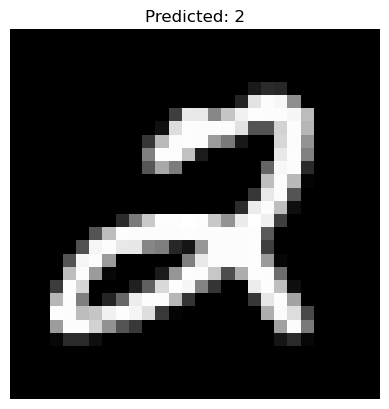

In [23]:
import matplotlib.pyplot as plt

plt.imshow(test_images[0].numpy().squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show()